### Importing Libraries
In this cell, We've import the necessary Python libraries for data analysis, data visualization, and machine learning. 

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

plt.style.use("default")

### Loading the Dataset
This cell loads the Premier League dataset using pandas. 
The dataset contains match statistics such as goals, shots, red cards, and match results. 
The first few rows (Head) are displayed to verify that the data has been loaded.

In [2]:
league_original = pd.read_csv("Premier_League.csv")
league = league_original.copy()
league.head()

,Date,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,HTAG,HTR,Referee,...,HST,AST,HF,AF,HC,AC,HY,AY,HR,AR
0,16/08/2024,Man United,Fulham,1,0,H,0,0,D,R Jones,...,5,2,12,10,7,8,2,3,0,0
1,17/08/2024,Ipswich,Liverpool,0,2,A,0,0,D,T Robinson,...,2,5,9,18,2,10,3,1,0,0
2,17/08/2024,Arsenal,Wolves,2,0,H,1,0,H,J Gillett,...,6,3,17,14,8,2,2,2,0,0
3,17/08/2024,Everton,Brighton,0,3,A,0,1,A,S Hooper,...,1,5,8,8,1,5,1,1,1,0
4,17/08/2024,Newcastle,Southampton,1,0,H,1,0,H,C Pawson,...,1,4,15,16,3,12,2,4,1,0


### Dataset Information
This cell displays basic information about the dataset, including the number of rows and columns (Shape of the dataset), data types, and missing values. 

In [3]:
print("Shape:", league.shape)
league.info()

Shape: (3420, 22)
<class 'pandas.DataFrame'>
RangeIndex: 3420 entries, 0 to 3419
Data columns (total 22 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   Date      3420 non-null   str  
 1   HomeTeam  3420 non-null   str  
 2   AwayTeam  3420 non-null   str  
 3   FTHG      3420 non-null   int64
 4   FTAG      3420 non-null   int64
 5   FTR       3420 non-null   str  
 6   HTHG      3420 non-null   int64
 7   HTAG      3420 non-null   int64
 8   HTR       3420 non-null   str  
 9   Referee   3420 non-null   str  
 10  HS        3420 non-null   int64
 11  AS        3420 non-null   int64
 12  HST       3420 non-null   int64
 13  AST       3420 non-null   int64
 14  HF        3420 non-null   int64
 15  AF        3420 non-null   int64
 16  HC        3420 non-null   int64
 17  AC        3420 non-null   int64
 18  HY        3420 non-null   int64
 19  AY        3420 non-null   int64
 20  HR        3420 non-null   int64
 21  AR        3420 non-null   int6

In [4]:
league.isnull().sum()

Date        0
HomeTeam    0
AwayTeam    0
FTHG        0
FTAG        0
FTR         0
HTHG        0
HTAG        0
HTR         0
Referee     0
HS          0
AS          0
HST         0
AST         0
HF          0
AF          0
HC          0
AC          0
HY          0
AY          0
HR          0
AR          0
dtype: int64

### Sorting Matches by Date
In this step, we convert the date column to datetime format and sort the dataset chronologically. 
This ensures that the model only uses historical data when calculating team statistics and avoids data leakage.

In [5]:
league["Date"] = pd.to_datetime(league["Date"], dayfirst=True)
league = league.sort_values("Date").reset_index(drop=True)

league[["Date", "HomeTeam", "AwayTeam", "FTR"]].head()

,Date,HomeTeam,AwayTeam,FTR
0,2016-01-10,Watford,Bournemouth,D
1,2016-01-10,West Ham,Middlesbrough,D
2,2016-01-10,Swansea,Liverpool,A
3,2016-01-10,Sunderland,West Brom,D
4,2016-01-10,Hull,Chelsea,A


## Data Wrangling

We use a copy of a dataset to not mess with the original figures. 

We also search for rows in which have missing values, We have 5 rows.

We fill the rows with missing values.

In [6]:
league_option = league.copy()


In [7]:
null_rows_idx = league_option.isnull().any(axis=1)
league_option.loc[null_rows_idx].head()

,Date,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,HTAG,HTR,Referee,...,HST,AST,HF,AF,HC,AC,HY,AY,HR,AR


In [8]:
league_option["FTAG"] = league_option["FTAG"].fillna(0)
league_option["FTHG"] = league_option["FTHG"].fillna(0)
league_option["HTAG"] = league_option["HTAG"].fillna(0)
league_option["HY"] = league_option["HY"].fillna(0)
league_option["AY"] = league_option["AY"].fillna(0)

### Match Results Distribution
This bar chart shows the distribution of match results: Home Win, Draw, and Away Win. 
This helps us understand whether the dataset is balanced and if some results occur more frequently than others.

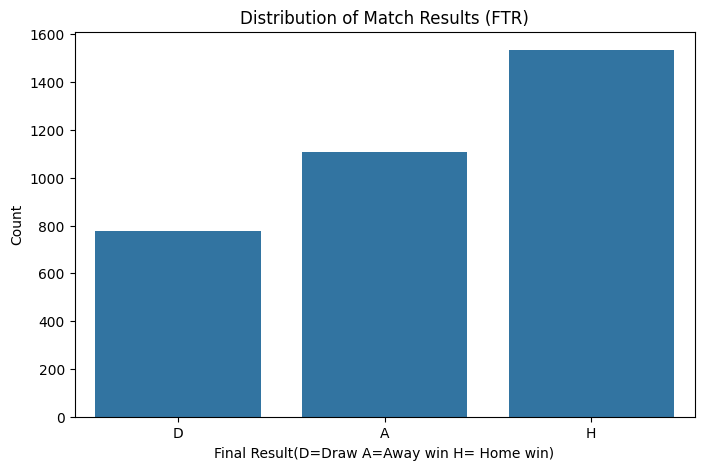

In [9]:
plt.figure(figsize=(8, 5))
sns.countplot(data=league, x="FTR")
plt.title("Distribution of Match Results (FTR)")
plt.xlabel("Final Result(D=Draw A=Away win H= Home win)")
plt.ylabel("Count")
plt.show()

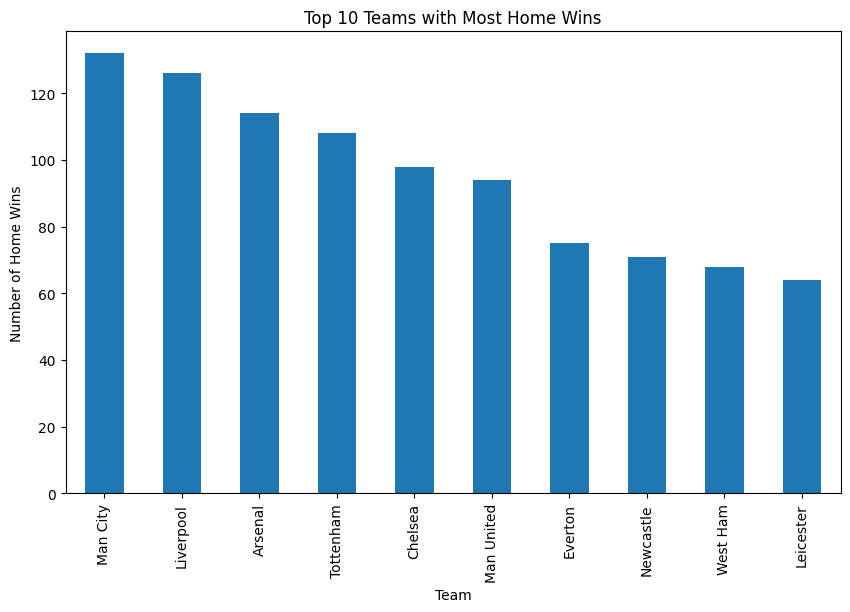

In [10]:
home_wins = league[league["FTR"] == "H"]["HomeTeam"].value_counts().head(10)

plt.figure(figsize=(10, 6))
home_wins.plot(kind="bar")
plt.title("Top 10 Teams with Most Home Wins")
plt.xlabel("Team")
plt.ylabel("Number of Home Wins")
plt.show()

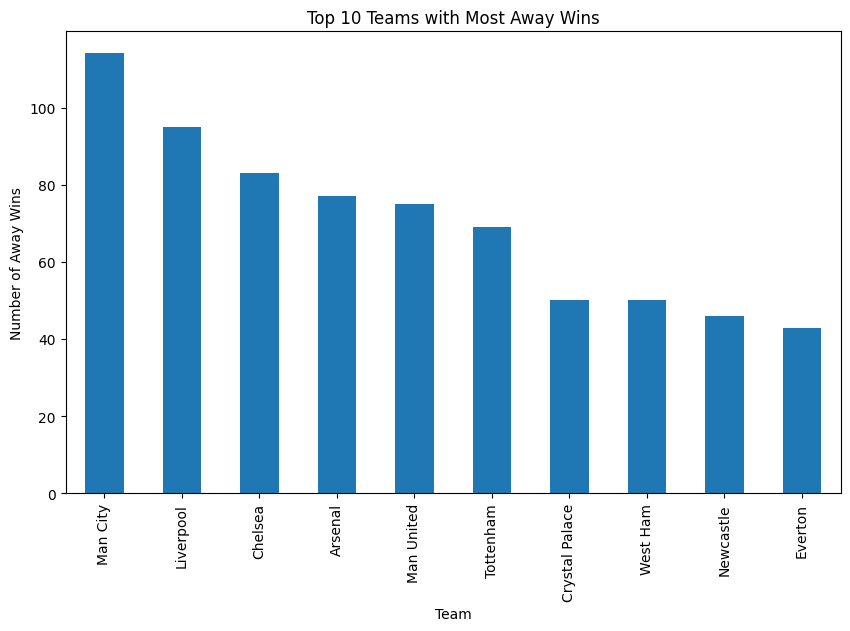

In [11]:
away_wins = league[league["FTR"] == "A"]["AwayTeam"].value_counts().head(10)

plt.figure(figsize=(10, 6))
away_wins.plot(kind="bar")
plt.title("Top 10 Teams with Most Away Wins")
plt.xlabel("Team")
plt.ylabel("Number of Away Wins")
plt.show()

### Features
In this section, we create new features based on historical team performance. 
These include average goals scored and conceded, shots on target, red cards, and win rate. 

In [12]:
league["Home_avg_goals_scored"] = (
    league.groupby("HomeTeam")["FTHG"]
    .expanding()
    .mean()
    .shift()
    .reset_index(level=0, drop=True)
)

league["Home_avg_goals_conceded"] = (
    league.groupby("HomeTeam")["FTAG"]
    .expanding()
    .mean()
    .shift()
    .reset_index(level=0, drop=True)
)

league["Home_avg_shots_on_target"] = (
    league.groupby("HomeTeam")["HST"]
    .expanding()
    .mean()
    .shift()
    .reset_index(level=0, drop=True)
)

league["Home_avg_red_cards"] = (
    league.groupby("HomeTeam")["HR"]
    .expanding()
    .mean()
    .shift()
    .reset_index(level=0, drop=True)
)

In [13]:
league["Away_avg_goals_scored"] = (
    league.groupby("AwayTeam")["FTAG"]
    .expanding()
    .mean()
    .shift()
    .reset_index(level=0, drop=True)
)

league["Away_avg_goals_conceded"] = (
    league.groupby("AwayTeam")["FTHG"]
    .expanding()
    .mean()
    .shift()
    .reset_index(level=0, drop=True)
)

league["Away_avg_shots_on_target"] = (
    league.groupby("AwayTeam")["AST"]
    .expanding()
    .mean()
    .shift()
    .reset_index(level=0, drop=True)
)

league["Away_avg_red_cards"] = (
    league.groupby("AwayTeam")["AR"]
    .expanding()
    .mean()
    .shift()
    .reset_index(level=0, drop=True)
)

In [14]:
league["Home_win"] = (league["FTR"] == "H").astype(int)
league["Away_win"] = (league["FTR"] == "A").astype(int)

league["Home_win_rate"] = (
    league.groupby("HomeTeam")["Home_win"]
    .expanding()
    .mean()
    .shift()
    .reset_index(level=0, drop=True)
)

league["Away_win_rate"] = (
    league.groupby("AwayTeam")["Away_win"]
    .expanding()
    .mean()
    .shift()
    .reset_index(level=0, drop=True)
)

In [15]:
print("Shape before dropna:", league.shape)
print("\nMissing values per column:")
print(league.isna().sum())

Shape before dropna: (3420, 34)

Missing values per column:
Date                        0
HomeTeam                    0
AwayTeam                    0
FTHG                        0
FTAG                        0
FTR                         0
HTHG                        0
HTAG                        0
HTR                         0
Referee                     0
HS                          0
AS                          0
HST                         0
AST                         0
HF                          0
AF                          0
HC                          0
AC                          0
HY                          0
AY                          0
HR                          0
AR                          0
Home_avg_goals_scored       1
Home_avg_goals_conceded     1
Home_avg_shots_on_target    1
Home_avg_red_cards          1
Away_avg_goals_scored       1
Away_avg_goals_conceded     1
Away_avg_shots_on_target    1
Away_avg_red_cards          1
Home_win                    0
Away_win  

In [16]:
league = league.dropna().reset_index(drop=True)

print("Shape after dropna:", league.shape)
league.head()

Shape after dropna: (3418, 34)


,Date,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,HTAG,HTR,Referee,...,Home_avg_shots_on_target,Home_avg_red_cards,Away_avg_goals_scored,Away_avg_goals_conceded,Away_avg_shots_on_target,Away_avg_red_cards,Home_win,Away_win,Home_win_rate,Away_win_rate
0,2016-01-10,Watford,Bournemouth,2,2,D,0,1,A,M Dean,...,5.771930,0.035088,1.210526,1.491228,3.947368,0.061404,0,0,0.631579,0.350877
1,2016-01-10,West Ham,Middlesbrough,1,1,D,0,0,D,N Swarbrick,...,3.438596,0.035088,1.432749,1.309942,4.830409,0.046784,0,0,0.263158,0.438596
2,2016-01-10,Swansea,Liverpool,1,2,A,1,0,H,M Oliver,...,3.473684,0.105263,1.414474,1.782895,4.052632,0.065789,0,1,0.157895,0.276316
3,2016-01-10,Sunderland,West Brom,1,1,D,0,1,A,S Attwell,...,3.789474,0.078947,0.936842,1.800000,3.294737,0.094737,0,0,0.315789,0.200000
4,2016-01-10,Hull,Chelsea,0,2,A,0,0,D,A Taylor,...,2.947368,0.131579,0.684211,1.631579,3.052632,0.052632,0,1,0.210526,0.210526


Here we define the input variables and the target variable. 
The features represent historical team performance statistics, and the target variable is the match result.

In [17]:
features = [
    "Home_avg_goals_scored",
    "Away_avg_goals_scored",
    "Home_avg_goals_conceded",
    "Away_avg_goals_conceded",
    "Home_avg_shots_on_target",
    "Away_avg_shots_on_target",
    "Home_avg_red_cards",
    "Away_avg_red_cards",
    "Home_win_rate",
    "Away_win_rate"
]

X = league[features]
y = league["FTR"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (3418, 10)
y shape: (3418,)


This heatmap shows the correlation between home and away wins.

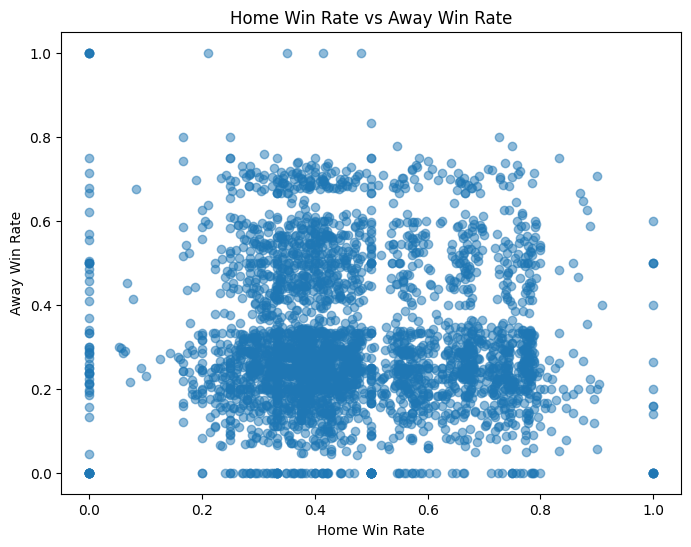

In [18]:
plt.figure(figsize=(8, 6))
plt.scatter(league["Home_win_rate"], league["Away_win_rate"], alpha=0.5)
plt.title("Home Win Rate vs Away Win Rate")
plt.xlabel("Home Win Rate")
plt.ylabel("Away Win Rate")
plt.show()

### Train-Test Split
The dataset is split into training and testing sets based on time, The model is trained using older matches and tested using newer matches

In [19]:
split_index = int(len(league) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)


Train size: (2734, 10)
Test size: (684, 10)


In [20]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### Random Forest 
Here we train a Random Forest model. Random Forest builds multiple decision trees and combines their predictions, which often improves prediction accuracy.

In [21]:
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced"
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))



Random Forest Accuracy: 0.5116959064327485


### Logistic Regression 
We train a Logistic Regression model using the training data and use it to predict match results for the test dataset.

In [22]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lr = LogisticRegression(max_iter=1000, class_weight="balanced")
lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))



Logistic Regression Accuracy: 0.4605263157894737


### K-Nearest Neighbors
KNN classifies a match result based on the most similar previous matches in the dataset.

In [23]:

param_grid = {
    'n_neighbors': list(range(1, 31)),
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

grid = GridSearchCV(KNeighborsClassifier(), param_grid, cv=5)
grid.fit(X_train_scaled, y_train)

print("Best params:", grid.best_params_)
print("KNN:", grid.best_score_)

knn = grid.best_estimator_

Best params: {'metric': 'euclidean', 'n_neighbors': 27, 'weights': 'uniform'}
KNN: 0.5094997020042724


For the machine predictions, we use different functions to get outputs such in this case the match statics. We use the team name as an input and if it plays home or away. The function then looks the team name in the data set and checks the different data. Also if there is no data we tell the user that there is no data for the team selected.

In [24]:
def get_team_latest_stats(team_name, is_home=True):
    if is_home:
        team_data = league[league["HomeTeam"] == team_name]
        if team_data.empty:
            raise ValueError(f"There is no data for: {team_name}")
        
        latest = team_data.iloc[-1]
        
        return {
            "avg_goals_scored": latest["Home_avg_goals_scored"],
            "avg_goals_conceded": latest["Home_avg_goals_conceded"],
            "avg_shots_on_target": latest["Home_avg_shots_on_target"],
            "avg_red_cards": latest["Home_avg_red_cards"],
            "win_rate": latest["Home_win_rate"]
        }
    
    else:
        team_data = league[league["AwayTeam"] == team_name]
        if team_data.empty:
            raise ValueError(f"no data for: {team_name}")
        
        latest = team_data.iloc[-1]
        
        return {
            "avg_goals_scored": latest["Away_avg_goals_scored"],
            "avg_goals_conceded": latest["Away_avg_goals_conceded"],
            "avg_shots_on_target": latest["Away_avg_shots_on_target"],
            "avg_red_cards": latest["Away_avg_red_cards"],
            "win_rate": latest["Away_win_rate"]
        }

As in the cell above we create a function to keep match features such as statistics like win rate or goals scored to obtain the statics. We also differenciate if the team is playing home or away with a True or False function. 

In [25]:
def build_match_features(home_team, away_team):
    home_stats = get_team_latest_stats(home_team, is_home=True)
    away_stats = get_team_latest_stats(away_team, is_home=False)
    
    match_features = pd.DataFrame([{
        "Home_avg_goals_scored": home_stats["avg_goals_scored"],
        "Away_avg_goals_scored": away_stats["avg_goals_scored"],
        "Home_avg_goals_conceded": home_stats["avg_goals_conceded"],
        "Away_avg_goals_conceded": away_stats["avg_goals_conceded"],
        "Home_avg_shots_on_target": home_stats["avg_shots_on_target"],
        "Away_avg_shots_on_target": away_stats["avg_shots_on_target"],
        "Home_avg_red_cards": home_stats["avg_red_cards"],
        "Away_avg_red_cards": away_stats["avg_red_cards"],
        "Home_win_rate": home_stats["win_rate"],
        "Away_win_rate": away_stats["win_rate"]
    }])
    
    return match_features

In this last function we have the prediction function. Here using the other two past functions we test the three models with different teams. This function will give the user who is wining the game in Home win or Away win format and will also give the percentage of every option. All this data is printed to the user.

In [26]:
def predict_match(home_team, away_team, model="logistic"):
    match_features = build_match_features(home_team, away_team)
    
    if model == "logistic":
        match_scaled = scaler.transform(match_features)
        prediction = lr.predict(match_scaled)[0]
        probabilities = lr.predict_proba(match_scaled)[0]
        classes = lr.classes_
    
    elif model == "random_forest":
        prediction = rf.predict(match_features)[0]
        probabilities = rf.predict_proba(match_features)[0]
        classes = rf.classes_
    
    elif model == "nearest_neighbors":
        match_scaled = scaler.transform(match_features)
        prediction = knn.predict(match_scaled)[0]
        probabilities = knn.predict_proba(match_scaled)[0]
        classes = knn.classes_
    
    else:
        raise ValueError("Model must be 'logistic' or 'random_forest' or 'nearest_neighbors'")
    
    result_map = {
        "H": "Home Win",
        "D": "Draw",
        "A": "Away Win"
    }
    
    print(f"Match: {home_team} vs {away_team}")
    print(f"Predicted result: {prediction} -> {result_map[prediction]}")
    print("\nProbabilities:")
    
    for cls, prob in zip(classes, probabilities):
        print(f"{result_map[cls]}: {prob:.2%}")
    
    return prediction, probabilities

Confusion Matrix - Random Forest:
[[110  15 103]
 [ 46  11 103]
 [ 56  11 229]]


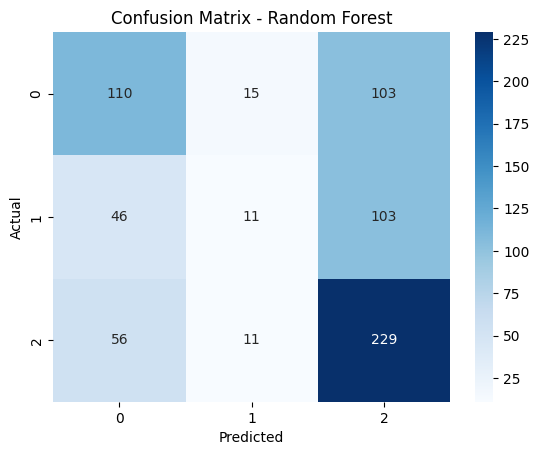

In [27]:
cm_rf = confusion_matrix(y_test, y_pred_rf)
print("Confusion Matrix - Random Forest:")
print(cm_rf)

sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Confusion Matrix - Logistic Regression:
[[104  75  49]
 [ 51  51  58]
 [ 68  68 160]]


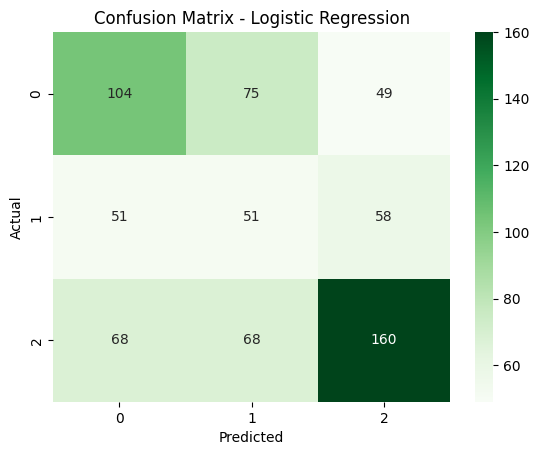

In [28]:
cm_lr = confusion_matrix(y_test, y_pred_lr)
print("Confusion Matrix - Logistic Regression:")
print(cm_lr)

sns.heatmap(cm_lr, annot=True, fmt="d", cmap="Greens")
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Confusion Matrix - KNN:
[[110   6 112]
 [ 55   4 101]
 [ 65   6 225]]


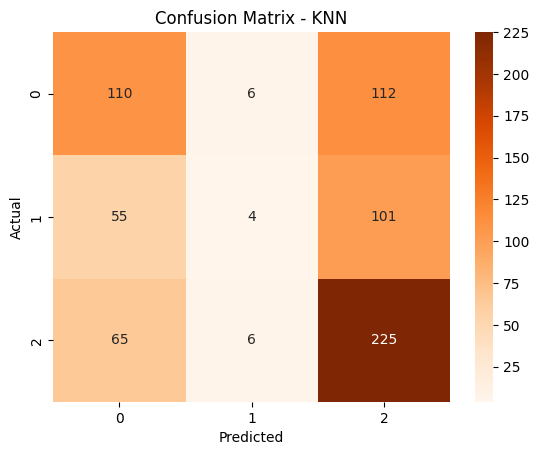

In [29]:
y_pred_knn = knn.predict(X_test_scaled)
cm_knn = confusion_matrix(y_test, y_pred_knn)
print("Confusion Matrix - KNN:")
print(cm_knn)

sns.heatmap(cm_knn, annot=True, fmt="d", cmap="Oranges")
plt.title("Confusion Matrix - KNN")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

This cell is for giving the user the option to choose an away and home team to predict who is winning using in this case Logistic Regression.

In [ ]:
home_team = input("Enter home team: ")
away_team = input("Enter away team: ")

predict_match(home_team, away_team, model="logistic")

Same thing as the cell above but in this case using Random Forest which it is as we've seen before the most accurate model.

In [ ]:
home_team = input("Enter home team: ")
away_team = input("Enter away team: ")

predict_match(home_team, away_team, model="random_forest")

Match: Nott'm Forest vs Burnley
Predicted result: H -> Home Win

Probabilities:
Away Win: 17.00%
Draw: 36.50%
Home Win: 46.50%


('H', array([0.17 , 0.365, 0.465]))

And finally the same as before but in this case using nearest neighbor model.

In [ ]:
home_team = input("Enter home team: ")
away_team = input("Enter away team: ")

predict_match(home_team, away_team, model="nearest_neighbors")

Match: Sunderland vs Nott'm Forest
Predicted result: A -> Away Win

Probabilities:
Away Win: 59.26%
Draw: 18.52%
Home Win: 22.22%


('A', array([0.59259259, 0.18518519, 0.22222222]))